In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("stopData.csv", low_memory=False)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552915 entries, 0 to 6552914
Data columns (total 16 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Stop Number                   int64  
 1   Form Reference Number         int64  
 2   Sex Code                      object 
 3   Descent Code                  object 
 4   Descent Description           object 
 5   Stop Date                     object 
 6   Stop Time                     object 
 7   Officer 1 Serial Number       float64
 8   Officer 1 Division Number     object 
 9   Division Description 1        object 
 10  Officer 2 Serial Number       float64
 11  Officer 2 Division Number     object 
 12  Division Description 2        object 
 13  Reporting District            object 
 14  Stop Type                     object 
 15  Post Stop Activity Indicator  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 799.9+ MB


In [8]:
# convert Stop Date to datetime
df["Stop Date"] = pd.to_datetime(df["Stop Date"], errors="coerce")

# extract year
df["year"] = df["Stop Date"].dt.year

# count stops per year
stops_per_year = df["year"].value_counts().sort_index()

print(stops_per_year)

year
2010    549940
2011    950636
2012    929796
2013    899445
2014    832809
2015    620345
2016    627677
2017    724384
2018    417883
Name: count, dtype: int64


In [12]:
raceBreakdown_df = (
    df.dropna(subset=["Descent Description"])
      .groupby("Descent Description")
      .size()
      .reset_index(name="stop_count")
      .sort_values("stop_count", ascending=False)
)

raceBreakdown_df["percent"] = (
    raceBreakdown_df["stop_count"] / raceBreakdown_df["stop_count"].sum() * 100
).round(2)

display(raceBreakdown_df)

raceBreakdown_df.to_excel("raceBreakdown_df.xlsx", index=False)

,Descent Description,stop_count,percent
3,HISPANIC,2882430,43.99
2,BLACK,1643308,25.08
6,WHITE,1426101,21.76
5,OTHER,366091,5.59
1,ASIAN,230350,3.52
0,AMERICAN INDIAN,4433,0.07
4,MULTI-DESCENTS,202,0.00


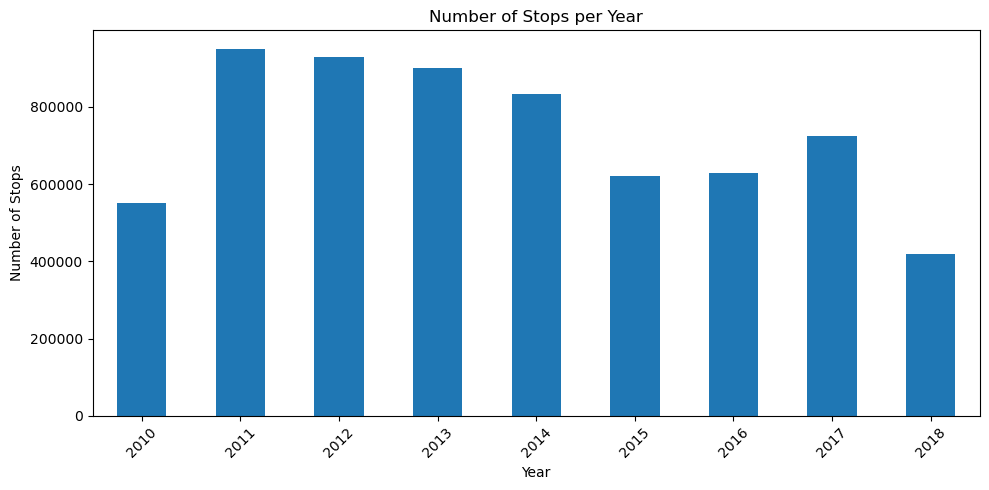

In [9]:
# # bar chart
# plt.figure(figsize=(10, 5))
# stops_per_year.plot(kind="bar")
# plt.title("Number of Stops per Year")
# plt.xlabel("Year")
# plt.ylabel("Number of Stops")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()